# Training GPT — Mixed Dataset

Let's train on a more diverse dataset by combining Shakespeare with some other text. Diversity should help the model generalize better.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
import math
from minigpt.model import GPTModel
from minigpt.data import create_dataloaders
from minigpt.generate import generate

## 1. Build Dataset

We'll grab Shakespeare and combine it with a chunk of modern-style text to get some variety.

In [18]:
import urllib.request
import os

data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)

# Shakespeare
filepath = os.path.join(data_dir, 'tinyshakespeare.txt')
if not os.path.exists(filepath):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, filepath)

with open(filepath, 'r') as f:
    shakespeare = f.read()

# Generate some synthetic "code-style" text with very different token distribution
code_text = ""
for i in range(500):
    code_text += f"def function_{i}(x_{i}, y_{i}):\n"
    code_text += f"    result_{i} = x_{i} * {i * 137 % 9973} + y_{i} ** {i % 7 + 1}\n"
    code_text += f"    if result_{i} > {i * 31 % 1000}:\n"
    code_text += f"        return result_{i} * {(i * 17 + 3) % 100}.{i % 100:02d}\n"
    code_text += f"    return -result_{i}\n\n"

# Interleave: chunks of Shakespeare then chunks of code
chunk_size = 2000
mixed = ""
s_pos = 0
c_pos = 0
while s_pos < len(shakespeare) and c_pos < len(code_text):
    mixed += shakespeare[s_pos:s_pos + chunk_size]
    s_pos += chunk_size
    mixed += code_text[c_pos:c_pos + chunk_size]
    c_pos += chunk_size
mixed += shakespeare[s_pos:]

print(f'Shakespeare: {len(shakespeare):,} chars')
print(f'Code text:   {len(code_text):,} chars')
print(f'Mixed total: {len(mixed):,} chars')

Shakespeare: 1,115,394 chars
Code text:   77,842 chars
Mixed total: 1,193,236 chars


## 2. Model + DataLoaders

In [19]:
SMALL_CONFIG = {
    'vocab_size': 50257,
    'context_length': 256,
    'emb_dim': 128,
    'n_heads': 4,
    'n_layers': 4,
    'drop_rate': 0.0,
    'qkv_bias': False,
}

tokenizer = tiktoken.get_encoding('gpt2')

train_loader, val_loader = create_dataloaders(
    mixed,
    tokenizer,
    max_length=SMALL_CONFIG['context_length'],
    stride=SMALL_CONFIG['context_length'],
    batch_size=16,
    train_ratio=0.9,
)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = GPTModel(SMALL_CONFIG).to(device)
print(f'Training batches: {len(train_loader)}')

Using device: mps
Training batches: 82


## 3. Training

We'll use a moderate LR of 3e-4 and track loss per step so we can see the fine-grained behavior.

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

NUM_EPOCHS = 5

step_losses = []
train_losses = []
val_losses = []
grad_norms = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(input_ids)
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Track gradient norm BEFORE stepping
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        step_losses.append(loss.item())

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for input_ids, target_ids in val_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            logits = model(input_ids)
            loss = torch.nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)),
                target_ids.view(-1)
            )
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}')

Epoch 1/5 — Train: 27.0625, Val: 17.9966
Epoch 2/5 — Train: 13.6123, Val: 11.2492
Epoch 3/5 — Train: 9.1375, Val: 8.6175
Epoch 4/5 — Train: 7.3808, Val: 7.4414
Epoch 5/5 — Train: 6.6022, Val: 6.9481


## 4. Visualize Training Dynamics

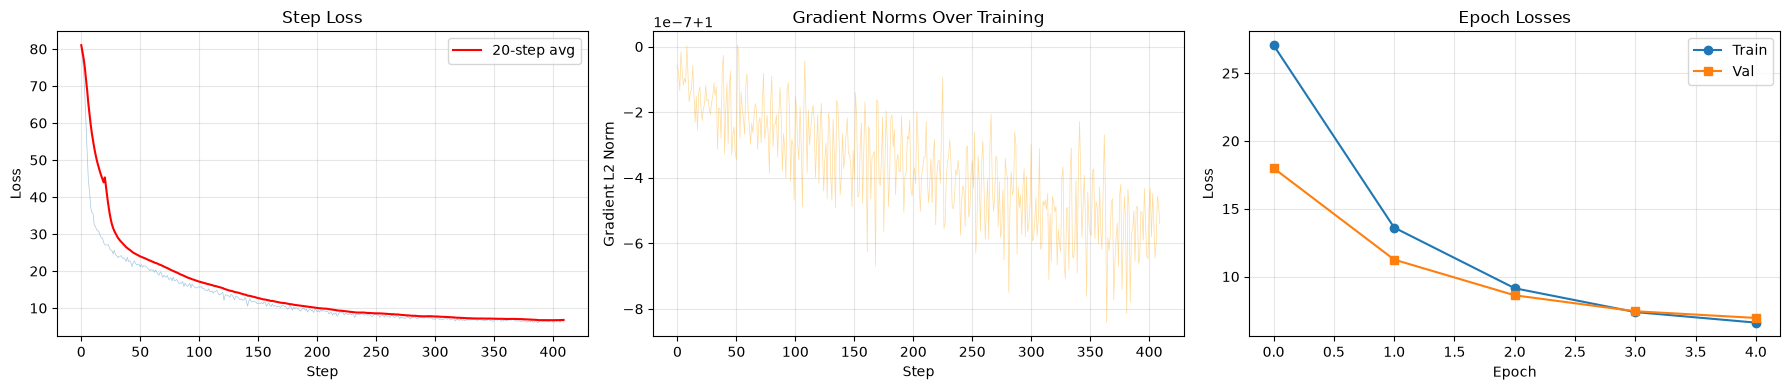

Gradient norm — min: 1.00, max: 1.00, mean: 1.00
Gradient spikes (>3x mean): 0 out of 410 steps (0.0%)


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Step-level loss
axes[0].plot(step_losses, alpha=0.4, linewidth=0.5)
# Running average
window = 20
if len(step_losses) > window:
    running_avg = [sum(step_losses[max(0,i-window):i+1])/min(i+1,window) for i in range(len(step_losses))]
    axes[0].plot(running_avg, color='red', linewidth=1.5, label=f'{window}-step avg')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Step Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gradient norms
axes[1].plot(grad_norms, alpha=0.4, linewidth=0.5, color='orange')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Gradient L2 Norm')
axes[1].set_title('Gradient Norms Over Training')
axes[1].grid(True, alpha=0.3)

# Epoch losses
axes[2].plot(train_losses, label='Train', marker='o')
axes[2].plot(val_losses, label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Epoch Losses')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats on gradient norms
print(f'Gradient norm — min: {min(grad_norms):.2f}, max: {max(grad_norms):.2f}, mean: {sum(grad_norms)/len(grad_norms):.2f}')
spikes = sum(1 for g in grad_norms if g > 3 * (sum(grad_norms)/len(grad_norms)))
print(f'Gradient spikes (>3x mean): {spikes} out of {len(grad_norms)} steps ({100*spikes/len(grad_norms):.1f}%)')

## 5. Look at the Loss Spikes

Let's check what's happening at the steps with the biggest loss jumps.

In [22]:
# Find steps where loss jumped significantly
jumps = []
for i in range(1, len(step_losses)):
    diff = step_losses[i] - step_losses[i-1]
    if diff > 0.5:
        jumps.append((i, step_losses[i-1], step_losses[i], diff, grad_norms[i]))

jumps.sort(key=lambda x: x[3], reverse=True)
print(f'Found {len(jumps)} significant loss jumps (>0.5)\n')
print(f'{"Step":>6} | {"Before":>8} | {"After":>8} | {"Jump":>8} | {"Grad Norm":>10}')
print('-' * 55)
for step, before, after, diff, gnorm in jumps[:15]:
    print(f'{step:>6} | {before:>8.3f} | {after:>8.3f} | {diff:>+8.3f} | {gnorm:>10.2f}')

Found 36 significant loss jumps (>0.5)

  Step |   Before |    After |     Jump |  Grad Norm
-------------------------------------------------------
   122 |   12.040 |   13.476 |   +1.435 |       1.00
   142 |   10.505 |   11.781 |   +1.276 |       1.00
    39 |   22.601 |   23.748 |   +1.146 |       1.00
    94 |   15.409 |   16.508 |   +1.098 |       1.00
    28 |   24.609 |   25.633 |   +1.025 |       1.00
   131 |   12.212 |   13.222 |   +1.010 |       1.00
    44 |   21.218 |   22.224 |   +1.006 |       1.00
    78 |   17.323 |   18.307 |   +0.984 |       1.00
    88 |   15.790 |   16.698 |   +0.909 |       1.00
   233 |    7.480 |    8.387 |   +0.907 |       1.00
    67 |   18.885 |   19.777 |   +0.892 |       1.00
   198 |    8.771 |    9.619 |   +0.847 |       1.00
   180 |    9.437 |   10.215 |   +0.777 |       1.00
   127 |   12.915 |   13.677 |   +0.763 |       1.00
   162 |   10.411 |   11.169 |   +0.758 |       1.00


## 6. Generate

In [8]:
model.eval()

prompt = 'ROMEO:'
input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)

with torch.no_grad():
    output_ids = generate(model, input_ids, max_new_tokens=100, context_length=SMALL_CONFIG['context_length'])

generated_text = tokenizer.decode(output_ids[0].tolist())
print(f'Generated:\n{generated_text}')

Generated:
ROMEO:

And I have.























































































IOLOLINGINGING
